<a href="https://colab.research.google.com/github/MarceloClash/Caculadora2024/blob/main/Clusterizacao_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Importa as bibliotecas necessárias
import pandas as pd                     # para trabalhar com tabelas / dados
import numpy as np                      # para fazer contas e arrays numéricos
from sklearn.cluster import KMeans      # o algoritmo de clusterização
import matplotlib.pyplot as plt         # para desenhar gráficos
import seaborn as sns                   # deixa os gráficos mais bonitos (opcional)

In [14]:
# 2. Cria um dataset pequeno e fácil de entender (5 clientes fictícios)
# Colunas: Gasto mensal (R$) e Idade
data = {
    'Cliente': ['Ana', 'Bruno', 'Carla', 'Diego', 'Elisa', 'Fábio', 'Gabi', 'Hugo', 'Marcelo'],
    'Gasto_mensal': [120, 450, 80, 600, 300, 150, 700, 250, 339],
    'Idade': [22, 35, 19, 42, 28, 24, 39, 31, 42]
}

# Transforma em DataFrame (tabela)
df = pd.DataFrame(data)

print("Dados originais:")
print(df)
print()

Dados originais:
   Cliente  Gasto_mensal  Idade
0      Ana           120     22
1    Bruno           450     35
2    Carla            80     19
3    Diego           600     42
4    Elisa           300     28
5    Fábio           150     24
6     Gabi           700     39
7     Hugo           250     31
8  Marcelo           339     42



In [16]:
# 3. Vamos usar apenas as duas colunas numéricas para clusterizar
X = df[['Gasto_mensal', 'Idade']]

# 4. Cria e treina o modelo K-Means
# n_clusters=3 → queremos 3 grupos
# random_state=42 → para o resultado ser sempre o mesmo quando rodar
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [17]:
# 5. Adiciona a coluna com o grupo (cluster) que cada cliente foi colocado
df['Cluster'] = kmeans.labels_

print("Dados com os clusters atribuídos:")
print(df)
print()

Dados com os clusters atribuídos:
   Cliente  Gasto_mensal  Idade  Cluster
0      Ana           120     22        0
1    Bruno           450     35        2
2    Carla            80     19        0
3    Diego           600     42        1
4    Elisa           300     28        2
5    Fábio           150     24        0
6     Gabi           700     39        1
7     Hugo           250     31        2
8  Marcelo           339     42        2



In [19]:
# 6. Mostra os centros dos clusters (ponto médio de cada grupo)
print("Centros dos clusters (média de Gasto e Idade):")
print(pd.DataFrame(kmeans.cluster_centers_, columns=['Gasto_mensal', 'Idade'],
                   index=[f'Cluster {i}' for i in range(3)]))

Centros dos clusters (média de Gasto e Idade):
           Gasto_mensal      Idade
Cluster 0    116.666667  21.666667
Cluster 1    650.000000  40.500000
Cluster 2    334.750000  34.000000


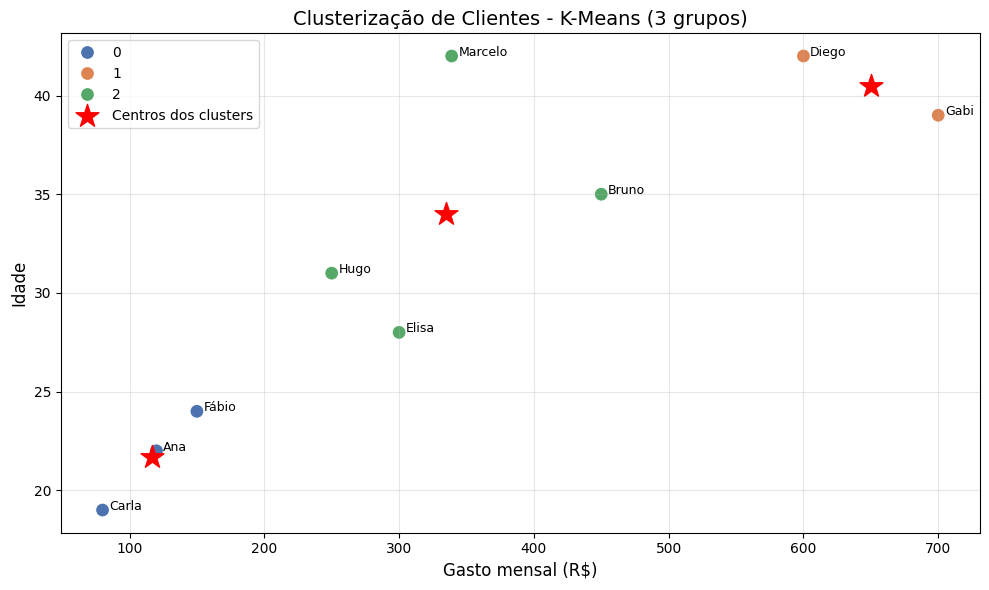

In [20]:
# 7. Faz o gráfico para visualizar
plt.figure(figsize=(10, 6))

# Scatter com cores diferentes para cada cluster
sns.scatterplot(data=df, x='Gasto_mensal', y='Idade',
                hue='Cluster', palette='deep', s=100)

# Mostra os centros dos clusters como estrelas vermelhas
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='*', s=300, label='Centros dos clusters')

# Coloca nome de cada cliente no ponto
for i, cliente in enumerate(df['Cliente']):
    plt.text(df['Gasto_mensal'][i]+5, df['Idade'][i],
             cliente, fontsize=9)

plt.title('Clusterização de Clientes - K-Means (3 grupos)', fontsize=14)
plt.xlabel('Gasto mensal (R$)', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# 8. Interpretação simples dos grupos
print("\nInterpretação dos clusters:")
print("Cluster 0 → Jovens com gasto baixo/médio")
print("Cluster 1 → Pessoas mais velhas com gasto alto")
print("Cluster 2 → Jovens adultos com gasto moderado")


Interpretação dos clusters:
Cluster 0 → Jovens com gasto baixo/médio
Cluster 1 → Pessoas mais velhas com gasto alto
Cluster 2 → Jovens adultos com gasto moderado
